# OpenAI 비전 모델 비교 — gpt-5-mini vs gpt-5-nano

같은 이미지 10장을 두 모델에 각각 넣고 결과를 나란히 본다.

- 표본: VLM 대상 182장 중 **픽셀이 큰 순서**(= 이미지 토큰이 많이 드는 순서) 상위 10장
- 모드: `openai_only` (PaddleOCR 없이 글자·표 구조·유형·요약을 한 번에 추출)
- 원본 데이터: `~/vision_cmp/comparison.json` (스크립트 `compare_mini_nano.py` 실행 결과)


In [1]:
import base64
import io
import json
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display
from PIL import Image

DATA_DIR = Path.home() / "vision_cmp"
MODELS = ["gpt-5-mini", "gpt-5-nano"]

rows = json.loads((DATA_DIR / "comparison.json").read_text(encoding="utf-8"))
selected = json.loads((DATA_DIR / "selected.json").read_text(encoding="utf-8"))
by_rank = {item["rank"]: item for item in selected}

print(f"결과 {len(rows)}행 / 이미지 {len(selected)}장")

결과 20행 / 이미지 10장


## 1. 비용·속도 요약

In [2]:
summary = (
    pd.DataFrame(rows)
    .groupby("model")
    .agg(
        입력토큰=("input_tokens", "sum"),
        출력토큰=("output_tokens", "sum"),
        비용USD=("cost_usd", "sum"),
        평균응답초=("latency_sec", "mean"),
    )
    .round({"비용USD": 4, "평균응답초": 1})
)
summary["182장_환산"] = (summary["비용USD"] / len(selected) * 182).round(3)
summary

,입력토큰,출력토큰,비용USD,평균응답초,182장_환산
model,,,,,
gpt-5-mini,31114,4539,0.0169,5.7,0.308
gpt-5-nano,38252,4604,0.0038,5.2,0.069


> `182장_환산`은 **상한값**이다. 표본이 가장 큰 이미지들이라 실제 평균 비용은 이보다 낮다.

## 2. 이미지별 판정·구조 보존 비교

In [3]:
frame = pd.DataFrame(rows)
pivot = frame.pivot(index="rank", columns="model")

table = pd.DataFrame({
    "문서": pivot[("doc_id", "gpt-5-mini")],
    "크기": pivot[("size", "gpt-5-mini")],
    "mini_판정": pivot[("image_type", "gpt-5-mini")],
    "mini_구분자": pivot[("has_table", "gpt-5-mini")].map({True: "O", False: "X"}),
    "mini_글자수": pivot[("text_length", "gpt-5-mini")],
    "nano_판정": pivot[("image_type", "gpt-5-nano")],
    "nano_구분자": pivot[("has_table", "gpt-5-nano")].map({True: "O", False: "X"}),
    "nano_글자수": pivot[("text_length", "gpt-5-nano")],
})
table

,문서,크기,mini_판정,mini_구분자,mini_글자수,nano_판정,nano_구분자,nano_글자수
rank,,,,,,,,
1,doc_087,2163x5723,form,X,1098,form,X,984
2,doc_030,5702x1945,logo,X,23,logo,X,13
3,doc_010,2468x3663,form,O,667,table,O,609
4,doc_030,2480x3508,logo,X,31,logo,X,14
5,doc_052,2480x3508,logo,X,38,logo,X,38
6,doc_097,2480x3507,form,X,1350,form,X,1659
7,doc_067,2479x3504,form,O,701,table,X,677
8,doc_030,2412x3296,form,O,1372,form,X,1465
9,doc_012,4030x1752,diagram,X,591,diagram,X,559


## 3. 이미지 원본과 두 모델의 추출 결과

In [4]:
def thumbnail(path: str, max_width: int = 420) -> str:
    """노트북 용량이 커지지 않도록 축소한 이미지를 data URI로 만든다."""
    with Image.open(path) as image:
        image = image.convert("RGB")
        ratio = max_width / image.width
        if ratio < 1:
            image = image.resize((max_width, int(image.height * ratio)))
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG", quality=80)
    return base64.b64encode(buffer.getvalue()).decode()


def escape(text: str) -> str:
    return text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


def panel(record: dict) -> str:
    return f"""
    <div style="flex:1; min-width:0; border:1px solid #999; border-radius:6px; padding:10px;">
      <div style="font-weight:bold; margin-bottom:6px;">{record['model']}</div>
      <div style="font-size:12px; margin-bottom:8px;">
        판정 <b>{record['image_type']}</b> &nbsp;|&nbsp; 구분자(|) {'O' if record['has_table'] else 'X'}
        &nbsp;|&nbsp; {record['text_length']}자 &nbsp;|&nbsp;
        입력 {record['input_tokens']:,} / 출력 {record['output_tokens']:,} 토큰
        &nbsp;|&nbsp; ${record['cost_usd']:.5f} &nbsp;|&nbsp; {record['latency_sec']}초
      </div>
      <div style="font-size:12px; margin-bottom:8px;"><i>{escape(record['summary'])}</i></div>
      <pre style="white-space:pre-wrap; font-size:12px; max-height:420px;
                  overflow:auto; margin:0; padding:8px; border:1px solid #ccc;
                  border-radius:4px;">{escape(record['text'])}</pre>
    </div>"""


def show(rank: int) -> None:
    item = by_rank[rank]
    records = [next(r for r in rows if r["rank"] == rank and r["model"] == m) for m in MODELS]
    panels = "".join(panel(record) for record in records)
    display(HTML(f"""
    <div style="margin:24px 0;">
      <h3 style="margin:0 0 8px 0;">
        {rank}. {item['doc_id']} &nbsp;
        <span style="font-weight:normal; font-size:13px;">
          {item['width']}x{item['height']} ({item['pixels']:,}px) · {item['file_name']}
        </span>
      </h3>
      <div style="display:flex; gap:12px; align-items:flex-start;">
        <img src="data:image/jpeg;base64,{thumbnail(item['path'])}"
             style="border:1px solid #999; border-radius:6px; flex:0 0 auto;">
        {panels}
      </div>
    </div>"""))

### 핵심 사례 먼저

- **7번 doc_067** — nano가 `table`로 판정해놓고 `|` 구분자를 넣지 않았다. 표 구조가 그대로 유실된다.
- **10번 doc_071** — nano가 글자를 `K R`로만 읽고, 요약에 존재하지 않는 기관명(`한국철도공단`)을 지어냈다.
- **2번 doc_030** — `세계 초월도시`를 nano가 `세계로도시`로 오독했다.


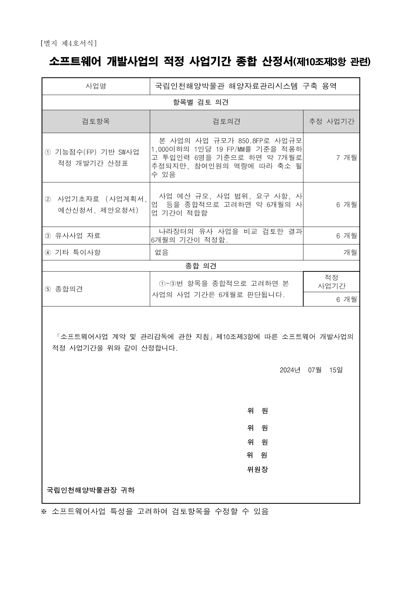


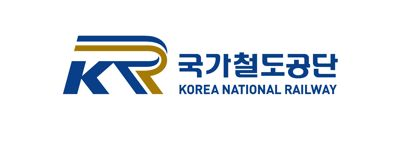


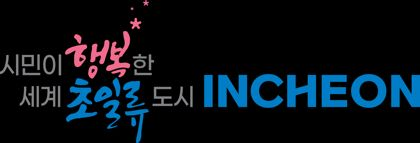

In [5]:
for rank in (7, 10, 2):
    show(rank)

### 나머지 전체


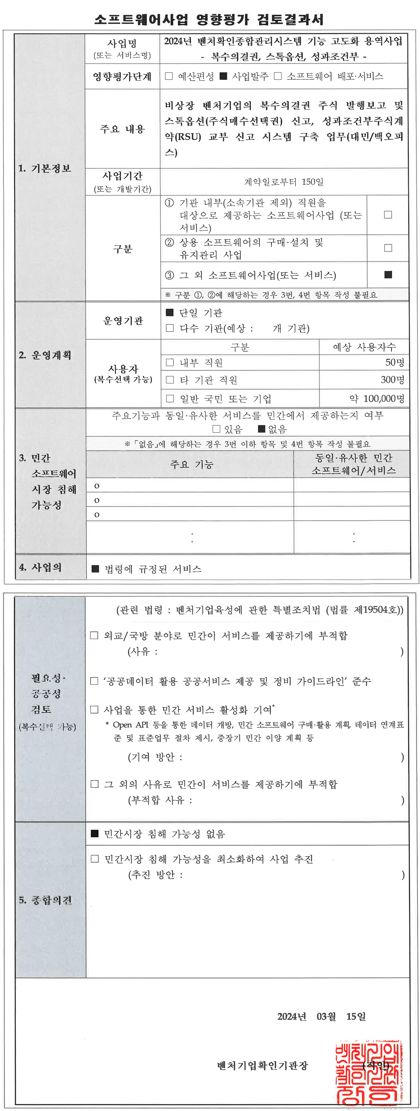


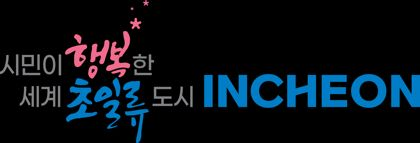


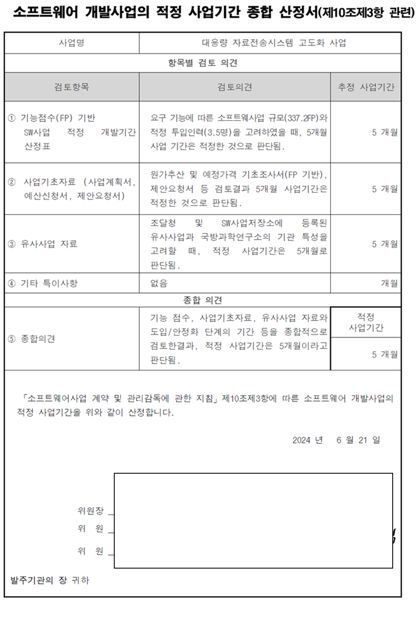


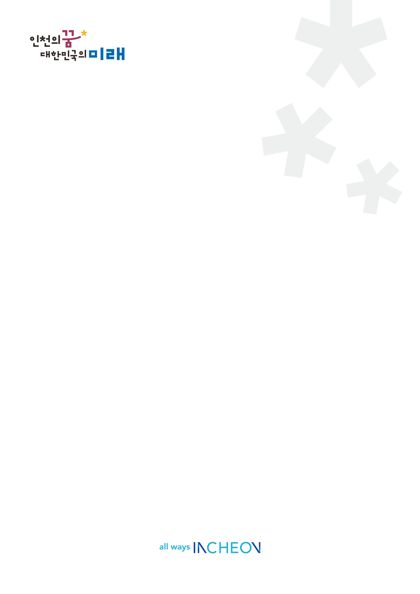


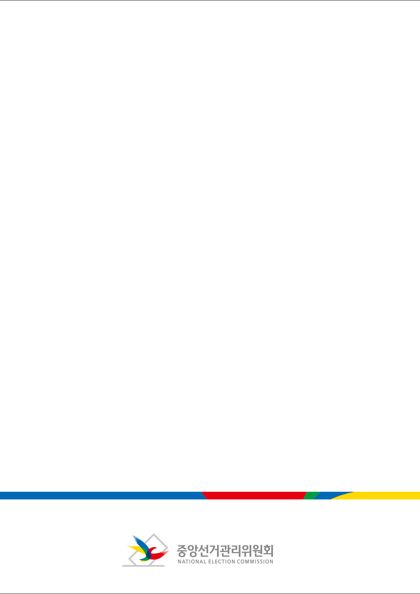


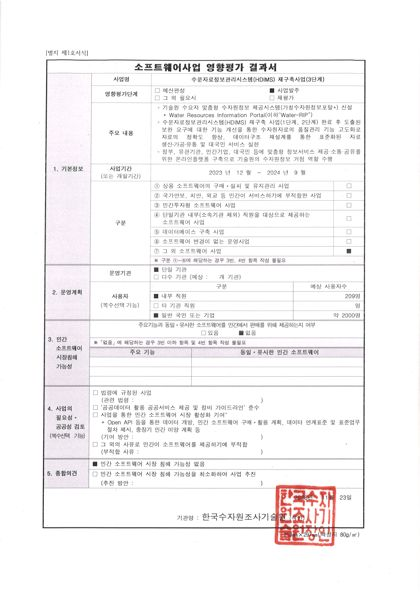


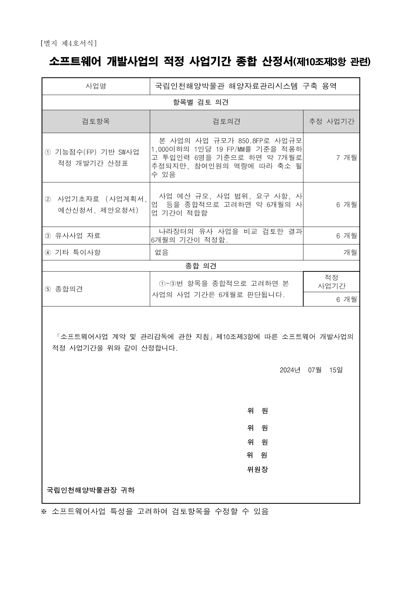


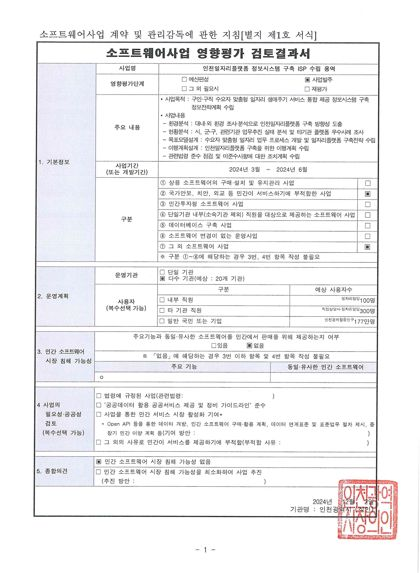


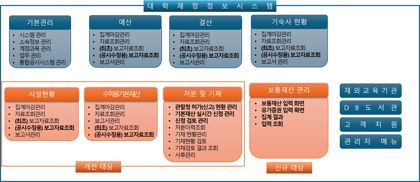


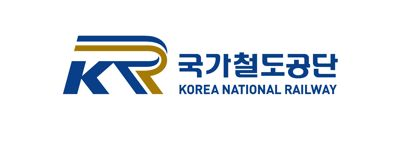

In [6]:
for rank in sorted(by_rank):
    show(rank)